**Cell 1: Imports**

In [1]:
import random
import networkx as nx
import matplotlib.pyplot as plt

**Cell 2: Define Graph**

In [2]:
# إنشاء جراف
G = nx.Graph()

edges = [
    (0,1),(0,2),(1,2),(1,3),
    (2,3),(3,4),(4,5),(5,0)
]

G.add_edges_from(edges)

NUM_NODES = G.number_of_nodes()
NUM_COLORS = 3

**Cell 3: Create Individual (Genotype)**

In [3]:
def create_individual():
    return [random.randint(0, NUM_COLORS-1) for _ in range(NUM_NODES)]

**Cell 4: Fitness Function**

In [4]:
def fitness(individual):
    conflicts = 0

    for u, v in G.edges():
        if individual[u] == individual[v]:
            conflicts += 1

    return -conflicts  # maximize

**Cell 5: Selection**

In [5]:
def select(pop):
    return max(random.sample(pop, 3), key=fitness)

**Cell 6: Crossover**

In [6]:
def crossover(p1, p2):
    point = random.randint(1, NUM_NODES-1)
    return p1[:point] + p2[point:]

**Cell 7: Mutation**

In [11]:
def mutate(ind):
    if random.random() < 0.3:
        i = random.randint(0, NUM_NODES-1)
        ind[i] = random.randint(0, NUM_COLORS-1)
    return ind

***Cell 8: GA Loop***

In [12]:
def run_ga():
    pop = [create_individual() for _ in range(20)]
    history = []

    for gen in range(50):
        new_pop = []

        for _ in range(len(pop)):
            p1 = select(pop)
            p2 = select(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

        best = max(pop, key=fitness)
        best_fit = fitness(best)
        history.append(best_fit)

        print(f"Gen {gen}, Conflicts = {-best_fit}")

    return best, history

**Cell 9: Run GA**

In [13]:
best_solution, history = run_ga()
print("\nBest Coloring:", best_solution)

Gen 0, Conflicts = 1
Gen 1, Conflicts = 1
Gen 2, Conflicts = 1
Gen 3, Conflicts = 1
Gen 4, Conflicts = 1
Gen 5, Conflicts = 1
Gen 6, Conflicts = 1
Gen 7, Conflicts = 1
Gen 8, Conflicts = 1
Gen 9, Conflicts = 1
Gen 10, Conflicts = 1
Gen 11, Conflicts = 1
Gen 12, Conflicts = 1
Gen 13, Conflicts = 0
Gen 14, Conflicts = 0
Gen 15, Conflicts = 0
Gen 16, Conflicts = 0
Gen 17, Conflicts = 0
Gen 18, Conflicts = 0
Gen 19, Conflicts = 0
Gen 20, Conflicts = 0
Gen 21, Conflicts = 0
Gen 22, Conflicts = 0
Gen 23, Conflicts = 0
Gen 24, Conflicts = 0
Gen 25, Conflicts = 0
Gen 26, Conflicts = 0
Gen 27, Conflicts = 0
Gen 28, Conflicts = 0
Gen 29, Conflicts = 0
Gen 30, Conflicts = 0
Gen 31, Conflicts = 0
Gen 32, Conflicts = 0
Gen 33, Conflicts = 0
Gen 34, Conflicts = 0
Gen 35, Conflicts = 0
Gen 36, Conflicts = 0
Gen 37, Conflicts = 0
Gen 38, Conflicts = 0
Gen 39, Conflicts = 0
Gen 40, Conflicts = 0
Gen 41, Conflicts = 0
Gen 42, Conflicts = 0
Gen 43, Conflicts = 0
Gen 44, Conflicts = 0
Gen 45, Conflicts = 

**Cell 10: Visualize Graph Coloring**

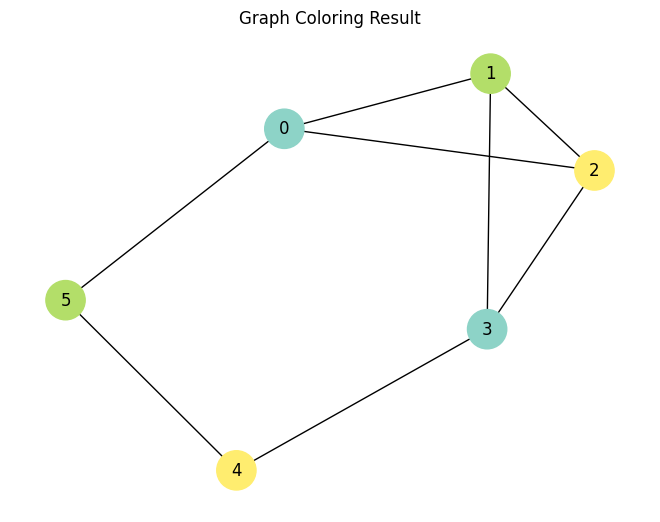

In [14]:
def visualize_graph(solution):
    color_map = solution
    pos = nx.spring_layout(G)

    nx.draw(G, pos,
            node_color=color_map,
            with_labels=True,
            cmap=plt.cm.Set3,
            node_size=800)

    plt.title("Graph Coloring Result")
    plt.show()

visualize_graph(best_solution)